# Netflix Data Project

Netflix is a popular streaming service that offers a wide variety of award-winning TV shows, movies, anime, and documentaries. This project explores Netflix dataset to derive meaningful insights and understand content types, release years, and show details.

These are some of the important columns that we'll focus on for meaningful insights in this project.

- column names: Variable Type

- show_id : string

- type : string

- title : string

- director : string

- cast : string

- country : string

- date_added : string

- release_year : integer

- rating : string

- duration : string

- listed_in : string

- description : string

### Loading the Libraries and Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Basic Information

Check the size of rows and columns of the dataset

In [4]:
print(f"Your rows are {df.shape[0]} and Your columns are {df.shape[1]}")

Your rows are 8807 and Your columns are 12


#### Removing Null Values

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
# Fill the big missing text columns with the word "Unknown"
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Delete the rows for the columns that are only missing a few values
df = df.dropna(subset=["date_added", "rating", "duration"])

# Check our work to make sure the null values are gone!
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   cast          8790 non-null   str  
 5   country       8790 non-null   str  
 6   date_added    8790 non-null   str  
 7   release_year  8790 non-null   int64
 8   rating        8790 non-null   str  
 9   duration      8790 non-null   str  
 10  listed_in     8790 non-null   str  
 11  description   8790 non-null   str  
dtypes: int64(1), str(11)
memory usage: 4.0 MB


1. Which country produced the most content?

In [8]:
df['country'].value_counts()
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

# Easy method
- we are here working with series

<Axes: xlabel='country'>

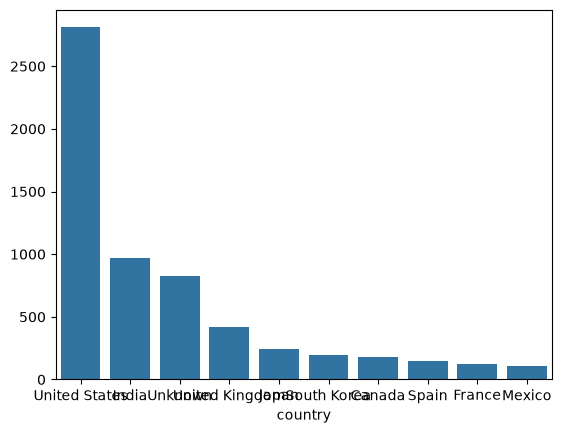

In [9]:
sns.barplot(x=top_countries.index,y=top_countries.values)

# Hard Method
- we are here working with datframe

In [10]:
df['country'].value_counts()
top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']
top_countries

,country,count
0,United States,2809
1,India,972
2,Unknown,829
3,United Kingdom,418
4,Japan,243
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


<Axes: xlabel='country', ylabel='count'>

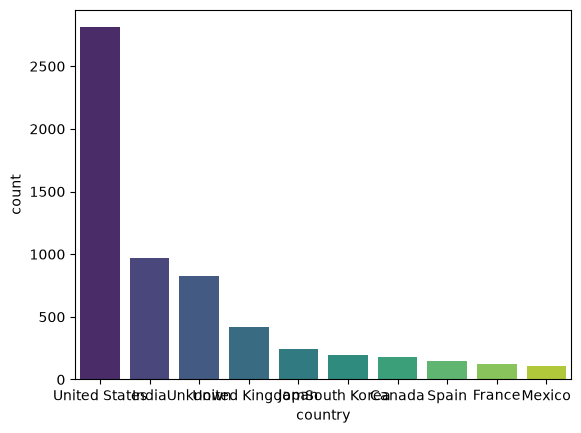

In [11]:
# 3. Added 'data=' at the very beginning
sns.barplot(data=top_countries, x='country', y='count',palette='viridis')

Text(0.5, 1.0, 'Most Content Producing Countries')

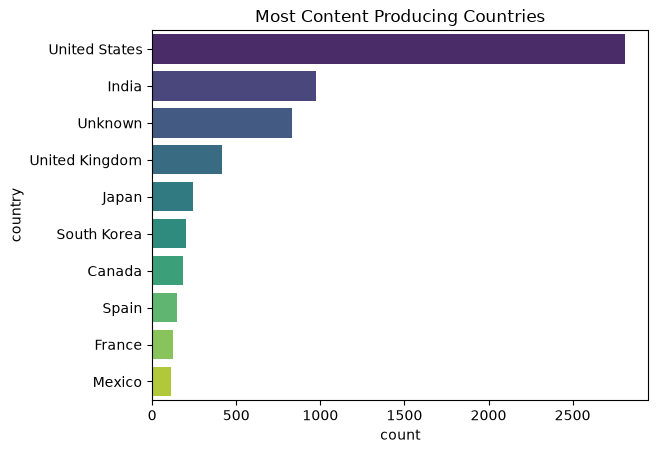

In [12]:
sns.barplot(data=top_countries, y='country', x='count',palette='viridis')
plt.title('Most Content Producing Countries')

2. Movies vs TV Shows Trends

Text(0, 0.5, 'Total Count')

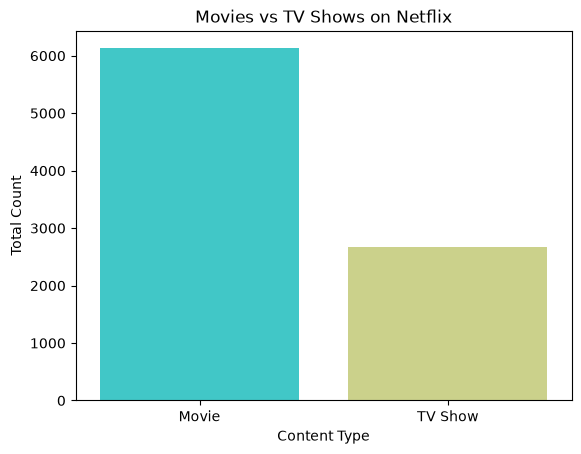

In [13]:
sns.countplot(data=df,x='type',palette='rainbow')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Total Count")

3. Content Type vs Content Rating

(array([   0.,  250.,  500.,  750., 1000., 1250., 1500., 1750., 2000.,
        2250.]),
 [Text(0.0, 0, '0'),
  Text(250.0, 0, '250'),
  Text(500.0, 0, '500'),
  Text(750.0, 0, '750'),
  Text(1000.0, 0, '1000'),
  Text(1250.0, 0, '1250'),
  Text(1500.0, 0, '1500'),
  Text(1750.0, 0, '1750'),
  Text(2000.0, 0, '2000'),
  Text(2250.0, 0, '2250')])

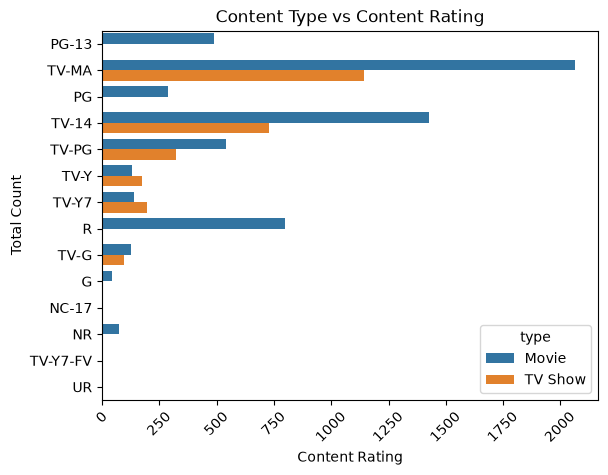

In [14]:
sns.countplot(data=df, y='rating', hue='type')
plt.title("Content Type vs Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Total Count")
plt.xticks(rotation=45)

In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


4. How long are most Movies? (Duration analysis)

In [16]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)

Text(0, 0.5, 'Number of Movies')

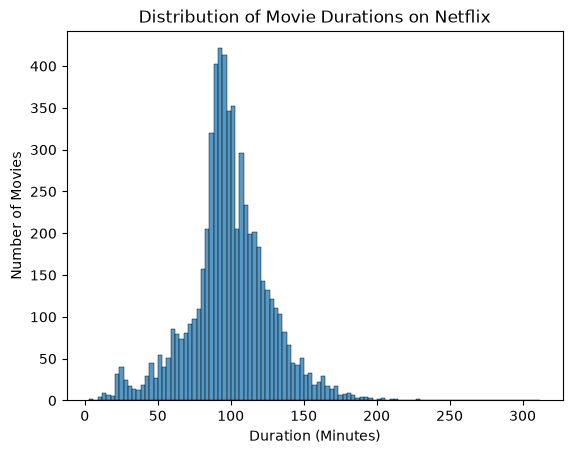

In [17]:
sns.histplot(data=movies_df,x='duration_minutes')
plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

# Key Directors and Cast

1. Most Frequent Directors



In [18]:
directors=df[df['director']!='Unknown']['director']
dir=directors.value_counts().head()
# count= directors['director'].value_counts().head()

Text(0, 0.5, 'Directors')

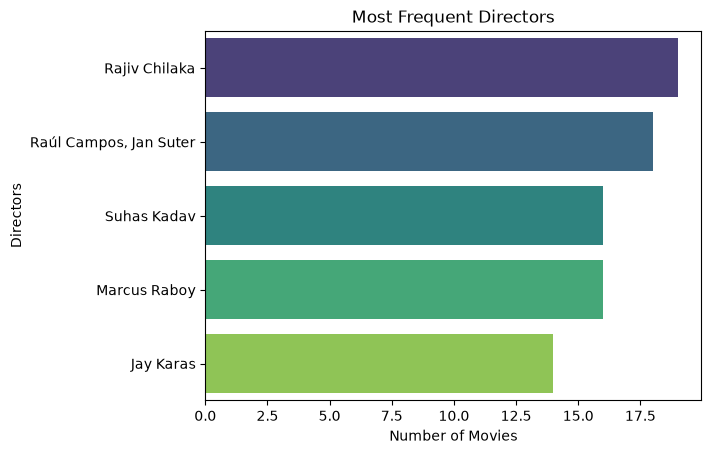

In [19]:
sns.barplot(y=dir.index,x=dir.values,palette='viridis')
plt.title("Most Frequent Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Directors")


2. Top Actors (Cast)

In [25]:
top_actors=df[df['cast']!='Unknown']['cast'].value_counts().head()
top_actors

cast
David Attenborough                                                                         19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil    14
Samuel West                                                                                10
Jeff Dunham                                                                                 7
David Spade, London Hughes, Fortune Feimster                                                6
Name: count, dtype: int64

Text(0, 0.5, 'Cast')

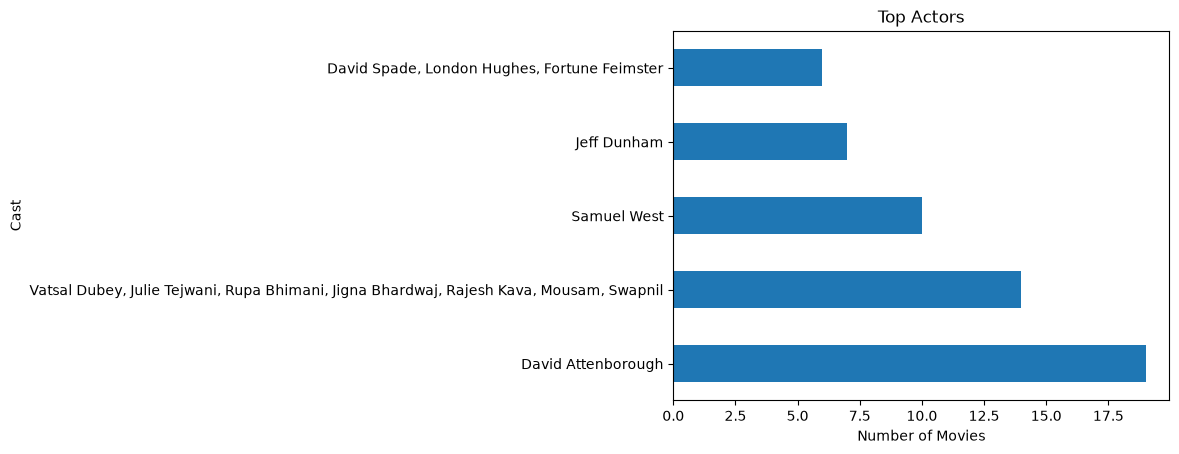

In [28]:
top_actors.plot(kind='barh')
plt.title("Top Actors")
plt.xlabel("Number of Movies")
plt.ylabel("Cast")


3. Most Popular Genres

In [29]:
popular=df[df['listed_in']!='Unknown']['listed_in'].value_counts().head()
popular

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64

Text(0, 0.5, 'Listed In')

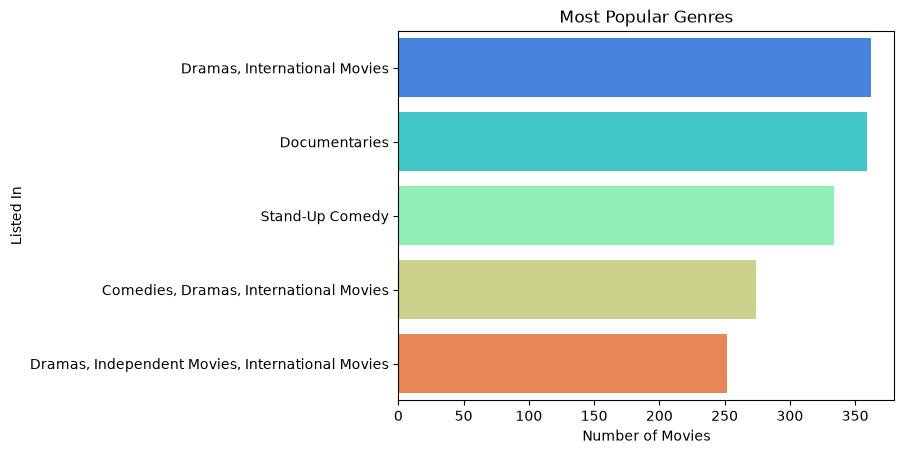

In [32]:
sns.barplot(x=popular.values,y=popular.index,palette='rainbow')
plt.title("Most Popular Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Listed In")

# Release Year Analysis

Most Content Released by Year

In [38]:
byyear=df['release_year'].value_counts().head()
byyear

release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
Name: count, dtype: int64

Text(0, 0.5, 'Number of Movies')

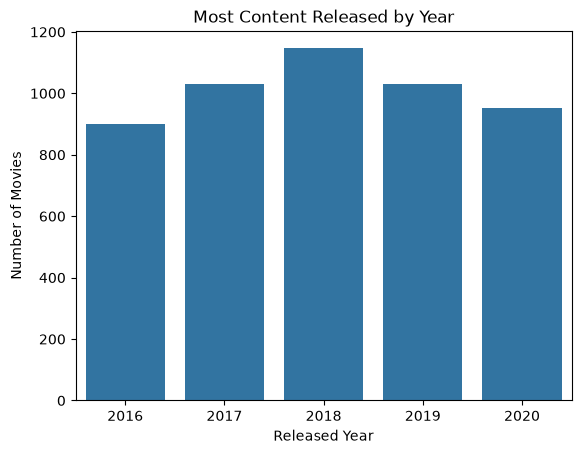

In [44]:
sns.barplot(x=byyear.index,y=byyear.values)
plt.title("Most Content Released by Year")
plt.xlabel("Released Year")
plt.ylabel("Number of Movies")

# Custom Questions & Insights

Q1: Which movie has the longest duration?

In [49]:
movies_only = df[df['type'] == 'Movie'].copy()
movies_only['duration_minutes'] = movies_only['duration'].str.replace(' min', '').astype(float)
longest_movie = movies_only.sort_values(by='duration_minutes', ascending=False)
longest_movie[['title', 'duration_minutes']].head(1)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0


Q2: Which TV show has the most seasons?

In [52]:
tv_shows=df[df['type'] == 'TV Show'].copy()
tv_shows['season_count'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)
most_seasons = tv_shows.sort_values(by='season_count', ascending=False)
most_seasons[['title', 'season_count']].head(1)

,title,season_count
548,Grey's Anatomy,17.0


In [50]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Q3: What is the oldest movie or TV show available on Netflix?

In [61]:
df.sort_values(by='release_year',ascending=True).head(1)[['title','release_year']]

,title,release_year
4250,Pioneers: First Women Filmmakers*,1925
